- http://fpaniaguapython.github.io/datos/empleados_sucios.csv
- Limpiar la muestra, tanto para faltantes como para outliers
	- Si no se puede calcular, se elimina si afecta a la estadística.
	- Si se puede calcular, la media para esa categoría.
- Cuanto ganan en promedio todos los Ingenieros de Software (34460, 34530, 34536 )
- Cuanto ganan en promedio los de Barcelona (36585, 33375, 33775)
- Cuanto ganan todos los ingenieros de software de Madrid (886077)
- Contar cuantas personas hay de cada categoría
- Mostrar diagrama de tartas con la distribución % por categorías profesionales

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('http://fpaniaguapython.github.io/datos/empleados_sucios.csv', header=None)
df.columns = ('id', 'nombre', 'apellido', 'categoria','ciudad','salario')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1001 non-null   int64  
 1   nombre     1000 non-null   object 
 2   apellido   1001 non-null   object 
 3   categoria  999 non-null    object 
 4   ciudad     1001 non-null   object 
 5   salario    999 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 47.1+ KB


# Anonimizar

In [ ]:
df['nombre']='Nombre'
df['apellido']='Apellido'
df.head()

,id,nombre,apellido,categoria,ciudad,salario
0,1,Nombre,Apellido,DevOps Engineer,Madrid,29128.0
1,2,Nombre,Apellido,Ingeniero de Software,Barcelona,43814.0
2,3,Nombre,Apellido,Científico de Datos,Barcelona,19010.0
3,4,Nombre,Apellido,Ingeniero de Software,Zaragoza,41165.0
4,5,Nombre,Apellido,Científico de Datos,Zaragoza,25191.0


# Detectar discrepancias en las cadenas de caracteres de ciudad

In [ ]:
contador_ciudad = df['ciudad'].value_counts() # Obtenemos el contador de elementos por ciudad.
contador_ciudad # Se observan ciudades con la primera letra en minúsculas y en mayúscula

,count
ciudad,
Granada,115
Barcelona,110
Zaragoza,107
Sevilla,104
Málaga,103
Madrid,97
Salamanca,94
Toledo,94
Valencia,92


# Normalización de los nombres de ciudad


In [ ]:
df['ciudad'] = df['ciudad'].str.capitalize()

# Detectar outliers

<Axes: >

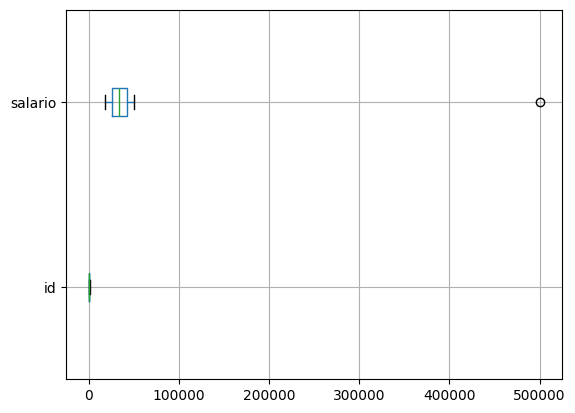

In [ ]:
# df[['salario']].plot()
#df[['salario']].boxplot(vert=False)
df.boxplot(vert=False)

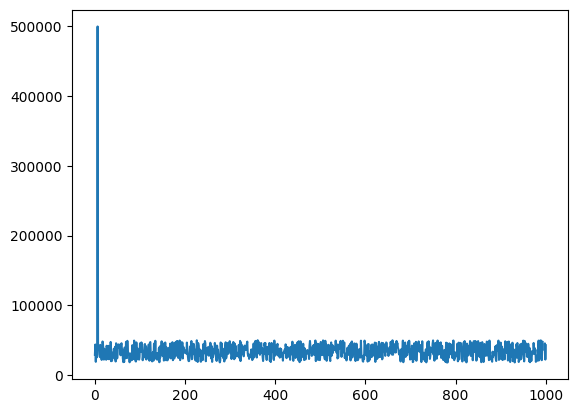

In [ ]:
plt.plot(df['salario']) # Nos ayuda a detectar visualmente los outliers


# Corregir outliers de salario

In [ ]:
from numpy import nan
df.loc[df['salario']>100000, 'salario']=nan # Asignamos nan a los que están fuera de rango
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1001 non-null   int64  
 1   nombre     1001 non-null   object 
 2   apellido   1001 non-null   object 
 3   categoria  999 non-null    object 
 4   ciudad     1001 non-null   object 
 5   salario    998 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 47.1+ KB


# Tratar datos faltantes

In [ ]:
df = df.dropna(subset='categoria') # Eliminamos los que tienen categoría faltante
df['salario'] = df['salario'].fillna(df['salario'].mean()) # Asignamos la media
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 1000
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         999 non-null    int64  
 1   nombre     999 non-null    object 
 2   apellido   999 non-null    object 
 3   categoria  999 non-null    object 
 4   ciudad     999 non-null    object 
 5   salario    999 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 54.6+ KB


- Cuanto ganan en promedio todos los Ingenieros de Software


In [ ]:
df_ingenieros = df[df['categoria']=='Ingeniero de Software']
salario_medio_ingenieros_software = df_ingenieros['salario'].mean()
salario_medio_ingenieros_software

np.float64(34457.66985904784)

- Cuanto ganan en promedio los de Barcelona


In [ ]:
df_barcelona = df[df['ciudad']=='Barcelona']
salario_medio_barcelona = df_barcelona['salario'].mean()
salario_medio_barcelona


np.float64(33775.77272727273)

- Cuanto ganan todos los ingenieros de software de Madrid (886077)


In [ ]:
df_ingenieros_software_madrid = df[(df['ciudad']=='Madrid') & (df['categoria']=='Ingeniero de Software')]
salarios_acumulados_ingenieros_software_madrid = df_ingenieros_software_madrid['salario'].sum()
salarios_acumulados_ingenieros_software_madrid

np.float64(886077.0)

- Contar cuantas personas hay de cada categoría


In [ ]:
contador_categorias = df['categoria'].value_counts()
contador_categorias


,count
categoria,
DevOps Engineer,206
Ingeniero de Software,206
Científico de Datos,197
Desarrollador Backend,196
Desarrollador Frontend,194


- Mostrar diagrama de tartas con la distribución % por categorías profesionales

<Axes: ylabel='count'>

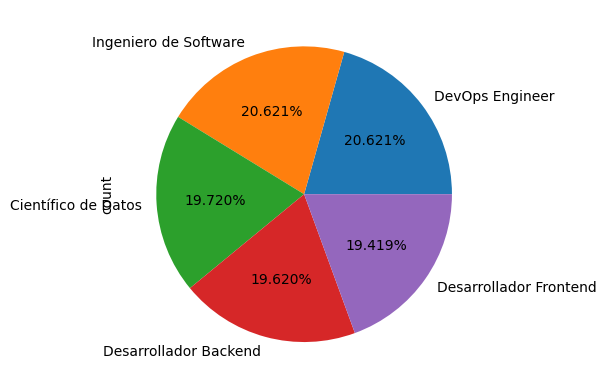

In [ ]:
contador_categorias = df['categoria'].value_counts()
contador_categorias.plot.pie(autopct='%1.3f%%')